# Análisis multivariado e influencia en contaminantes

Este notebook trabaja con la misma base horaria de contaminantes de la Ciudad de México y desarrolla:

1. una tabla con un renglón por estación–hora y una columna por contaminante;
2. covarianza y correlación entre CO y NOX;
3. eigenvalores de la matriz de correlación con datos faltantes (pares disponibles) y sin faltantes (casos completos);
4. regresiones de PM2.5 contra los demás contaminantes y luego solamente contra gases, con $R^2$ y VIF;
5. construcción de la matriz sombrero $H$ en una estación y una semana, comprobando $H^2=H$ y $\operatorname{tr}(H)=p$, seguida del cálculo del *leverage* de todas las observaciones sin construir $H$;
6. distancia de Cook, comparación de las 10 observaciones más influyentes con las de mayor *leverage* y reajuste sin ellas.

Las comparaciones se realizan sobre muestras completas para cada modelo. Se conserva una copia con faltantes para el análisis de correlación por pares.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")

COLOR = "#2463A6"
COLOR_2 = "#D1495B"

## A. Tabla estación–hora × contaminante

El CSV contiene nueve líneas de metadatos antes del encabezado. Después de leerlo, se verifica que no existan duplicados para una misma combinación de fecha, estación y contaminante; esto permite usar `pivot` sin agregar ni promediar valores.

In [2]:
ruta_csv = Path("contaminantes_2026 (1).csv")
if not ruta_csv.exists():
    raise FileNotFoundError(
        f"No se encontró {ruta_csv.name}. Ejecute el notebook desde su propia carpeta."
    )

datos_largos = pd.read_csv(
    ruta_csv,
    skiprows=9,
    encoding="utf-8",
    parse_dates=["date"],
    dtype={"id_station": "string", "id_parameter": "string"},
)

llave = ["date", "id_station", "id_parameter"]
n_duplicados = datos_largos.duplicated(llave).sum()
if n_duplicados:
    raise ValueError(f"Hay {n_duplicados:,} mediciones duplicadas para estación–hora–contaminante.")

tabla = (
    datos_largos
    .pivot(index=["date", "id_station"], columns="id_parameter", values="valor")
    .reset_index()
    .sort_values(["id_station", "date"], ignore_index=True)
)
tabla.columns.name = None

contaminantes = [
    c for c in ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "PMCO", "SO2"]
    if c in tabla.columns
]
tabla = tabla[["date", "id_station", *contaminantes]]

print(f"Base larga: {len(datos_largos):,} renglones")
print(f"Tabla ancha: {len(tabla):,} estaciones–hora × {len(contaminantes)} contaminantes")
print(f"Periodo: {tabla['date'].min()} a {tabla['date'].max()}")
print(f"Estaciones: {tabla['id_station'].nunique()}")
display(tabla.head())

Base larga: 1,556,928 renglones
Tabla ancha: 172,992 estaciones–hora × 9 contaminantes
Periodo: 2026-01-01 00:00:00 a 2026-07-31 23:00:00
Estaciones: 34


,date,id_station,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
0,2026-01-01 00:00:00,ACO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 01:00:00,ACO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-01 02:00:00,ACO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-01 03:00:00,ACO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-01 04:00:00,ACO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
resumen_faltantes = pd.DataFrame({
    "observados": tabla[contaminantes].notna().sum(),
    "faltantes": tabla[contaminantes].isna().sum(),
    "porcentaje_faltante": 100 * tabla[contaminantes].isna().mean(),
})
display(resumen_faltantes)

,observados,faltantes,porcentaje_faltante
CO,111097,61895,35.7791
NO,99167,73825,42.6754
NO2,110119,62873,36.3445
NOX,99168,73824,42.6748
O3,124470,48522,28.0487
PM10,76201,96791,55.9511
PM2.5,58729,114263,66.051
PMCO,36171,136821,79.0909
SO2,103046,69946,40.4331


## B. Covarianza y correlación de CO con NOX

Sí son distintas. La covarianza conserva las unidades y cambia si se reescala alguna variable; la correlación estandariza ambas variables, no tiene unidades y siempre está entre −1 y 1. Para compararlas justamente se usan exactamente los mismos pares observados de CO y NOX.

In [4]:
co_nox = tabla[["CO", "NOX"]].dropna()
cov_co_nox = co_nox["CO"].cov(co_nox["NOX"])
corr_co_nox = co_nox["CO"].corr(co_nox["NOX"])
corr_desde_cov = cov_co_nox / (co_nox["CO"].std(ddof=1) * co_nox["NOX"].std(ddof=1))

comparacion_co_nox = pd.Series({
    "n_pares_completos": len(co_nox),
    "covarianza_CO_NOX": cov_co_nox,
    "correlacion_CO_NOX": corr_co_nox,
    "cov/(s_CO*s_NOX)": corr_desde_cov,
    "diferencia_de_verificacion": corr_co_nox - corr_desde_cov,
}, name="CO vs. NOX").to_frame()
display(comparacion_co_nox)

print(
    "La igualdad corr(CO, NOX) = cov(CO, NOX)/(s_CO·s_NOX) se cumple; "
    "covarianza y correlación no son la misma medida."
)

,CO vs. NOX
n_pares_completos,"92,392"
covarianza_CO_NOX,11.5867
correlacion_CO_NOX,0.86563
cov/(s_CO*s_NOX),0.86563
diferencia_de_verificacion,7.77156e-16


La igualdad corr(CO, NOX) = cov(CO, NOX)/(s_CO·s_NOX) se cumple; covarianza y correlación no son la misma medida.


## C. Eigenvalores de la matriz de correlación, con y sin faltantes

- **Con faltantes:** `pandas.corr()` calcula cada correlación con todos los pares disponibles para esas dos variables. Como distintas celdas pueden provenir de muestras diferentes, la matriz resultante no está obligada a ser semidefinida positiva y puede tener eigenvalores negativos pequeños (o incluso apreciables).
- **Sin faltantes:** primero se conservan únicamente las estaciones–hora con los nueve contaminantes observados. Toda la matriz usa entonces la misma muestra y, salvo error numérico, sus eigenvalores son no negativos.

In [5]:
# Matriz con faltantes: eliminación por pares.
corr_pares = tabla[contaminantes].corr()
n_pares = tabla[contaminantes].notna().astype(int).T @ tabla[contaminantes].notna().astype(int)

# Matriz sin faltantes: eliminación por lista/casos completos.
casos_completos = tabla.dropna(subset=contaminantes)
corr_completa = casos_completos[contaminantes].corr()

eig_pares = np.linalg.eigvalsh(corr_pares.to_numpy())[::-1]
eig_completa = np.linalg.eigvalsh(corr_completa.to_numpy())[::-1]
tabla_eigen = pd.DataFrame({
    "orden": np.arange(1, len(contaminantes) + 1),
    "con_faltantes_pares_disponibles": eig_pares,
    "sin_faltantes_casos_completos": eig_completa,
})

print(f"Casos completos para los {len(contaminantes)} contaminantes: {len(casos_completos):,}")
display(corr_pares.style.format("{:.3f}").set_caption("Correlación con pares disponibles"))
display(n_pares.style.format("{:,.0f}").set_caption("Número de pares usado en cada correlación"))
display(corr_completa.style.format("{:.3f}").set_caption("Correlación con casos completos"))
display(tabla_eigen)
print(f"Suma de eigenvalores (pares):     {eig_pares.sum():.12g}")
print(f"Suma de eigenvalores (completos): {eig_completa.sum():.12g}")
print("Ambas sumas deben ser iguales al número de variables porque tr(R) = 9.")

Casos completos para los 9 contaminantes: 17,955


,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
CO,1.000,0.755,0.769,0.866,-0.338,0.422,0.400,0.414,0.159
NO,0.755,1.000,0.484,0.939,-0.384,0.260,0.192,0.293,0.092
NO2,0.769,0.484,1.000,0.755,-0.434,0.399,0.339,0.412,0.161
NOX,0.866,0.939,0.755,1.000,-0.454,0.353,0.284,0.378,0.129
O3,-0.338,-0.384,-0.434,-0.454,1.000,0.077,0.182,0.037,-0.036
PM10,0.422,0.260,0.399,0.353,0.077,1.000,0.846,0.841,0.230
PM2.5,0.400,0.192,0.339,0.284,0.182,0.846,1.000,0.438,0.237
PMCO,0.414,0.293,0.412,0.378,0.037,0.841,0.438,1.000,0.237
SO2,0.159,0.092,0.161,0.129,-0.036,0.230,0.237,0.237,1.000


,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
CO,"111,097","92,392","98,762","92,392","107,113","64,237","49,403","29,241","96,874"
NO,"92,392","99,167","99,167","99,166","95,630","57,753","42,695","22,094","84,867"
NO2,"98,762","99,167","110,119","99,168","106,508","65,657","50,596","29,995","91,209"
NOX,"92,392","99,166","99,168","99,168","95,631","57,755","42,694","22,094","84,868"
O3,"107,113","95,630","106,508","95,631","124,470","69,490","53,807","33,408","99,972"
PM10,"64,237","57,753","65,657","57,755","69,490","76,201","40,679","36,171","60,528"
PM2.5,"49,403","42,695","50,596","42,694","53,807","40,679","58,729","36,171","43,412"
PMCO,"29,241","22,094","29,995","22,094","33,408","36,171","36,171","36,171","27,219"
SO2,"96,874","84,867","91,209","84,868","99,972","60,528","43,412","27,219","103,046"


,CO,NO,NO2,NOX,O3,PM10,PM2.5,PMCO,SO2
CO,1.000,0.760,0.812,0.882,-0.337,0.482,0.397,0.414,0.171
NO,0.760,1.000,0.528,0.936,-0.383,0.292,0.185,0.311,0.142
NO2,0.812,0.528,1.000,0.793,-0.426,0.492,0.392,0.439,0.196
NOX,0.882,0.936,0.793,1.000,-0.451,0.414,0.296,0.405,0.183
O3,-0.337,-0.383,-0.426,-0.451,1.000,0.156,0.241,0.012,-0.069
PM10,0.482,0.292,0.492,0.414,0.156,1.000,0.854,0.827,0.282
PM2.5,0.397,0.185,0.392,0.296,0.241,0.854,1.000,0.415,0.259
PMCO,0.414,0.311,0.439,0.405,0.012,0.827,0.415,1.000,0.216
SO2,0.171,0.142,0.196,0.183,-0.069,0.282,0.259,0.216,1.000


,orden,con_faltantes_pares_disponibles,sin_faltantes_casos_completos
0,1,4.30334,4.45567
1,2,1.99286,1.97827
2,3,0.918607,0.912216
3,4,0.657686,0.644521
4,5,0.558406,0.55258
5,6,0.428957,0.334203
6,7,0.143673,0.122036
7,8,7.40368e-05,0.00037796
8,9,-0.00361165,0.000131096


Suma de eigenvalores (pares):     9
Suma de eigenvalores (completos): 9
Ambas sumas deben ser iguales al número de variables porque tr(R) = 9.


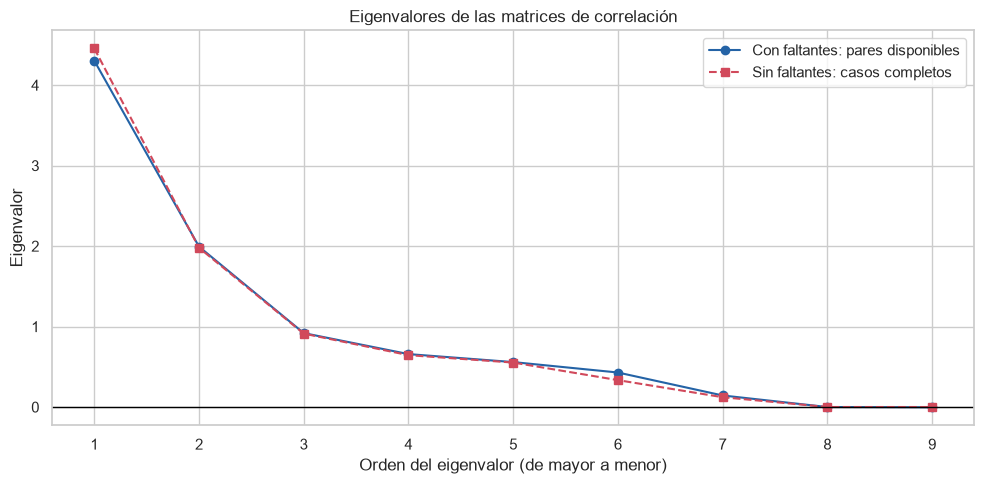

In [6]:
x = np.arange(1, len(contaminantes) + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, eig_pares, "o-", label="Con faltantes: pares disponibles", color=COLOR)
ax.plot(x, eig_completa, "s--", label="Sin faltantes: casos completos", color=COLOR_2)
ax.axhline(0, color="black", linewidth=1)
ax.set(
    title="Eigenvalores de las matrices de correlación",
    xlabel="Orden del eigenvalor (de mayor a menor)",
    ylabel="Eigenvalor",
    xticks=x,
)
ax.legend()
plt.tight_layout()
plt.show()

## D. PM2.5 contra los demás contaminantes: $R^2$ y VIF

Se ajustan dos modelos OLS con intercepto:

1. **Todos:** PM2.5 contra los otros ocho contaminantes.
2. **Sólo gases:** PM2.5 contra CO, NO, NO2, NOX, O3 y SO2.

El VIF se calcula para cada predictor, siempre incluyendo un intercepto en la regresión auxiliar. Dos relaciones del sistema de medición requieren atención:

- `NOX` es aproximadamente `NO + NO2`; incluir los tres causa colinealidad estructural.
- `PMCO` representa la fracción gruesa, aproximadamente `PM10 - PM2.5`; usar simultáneamente PM10 y PMCO para explicar PM2.5 introduce una identidad casi determinista y puede inflar artificialmente el $R^2$.

In [7]:
objetivo = "PM2.5"
pred_todos = [c for c in contaminantes if c != objetivo]
pred_gases = [c for c in ["CO", "NO", "NO2", "NOX", "O3", "SO2"] if c in tabla.columns]

def ajustar_ols(data, predictores, objetivo="PM2.5"):
    X = sm.add_constant(data[predictores], has_constant="add")
    y = data[objetivo]
    return sm.OLS(y, X).fit(), X, y

def calcular_vif(X):
    # El intercepto se usa en cada regresión auxiliar, pero no se reporta.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        valores = [variance_inflation_factor(X.to_numpy(), i) for i in range(1, X.shape[1])]
    return pd.DataFrame({"predictor": X.columns[1:], "VIF": valores}).sort_values(
        "VIF", ascending=False, ignore_index=True
    )

datos_todos = tabla.dropna(subset=[objetivo, *pred_todos]).reset_index(drop=True)
datos_gases = tabla.dropna(subset=[objetivo, *pred_gases]).reset_index(drop=True)

modelo_todos, X_todos, y_todos = ajustar_ols(datos_todos, pred_todos)
modelo_gases, X_gases, y_gases = ajustar_ols(datos_gases, pred_gases)

comparacion_modelos = pd.DataFrame({
    "modelo": ["Todos los contaminantes", "Sólo gases (incluye NO, NO2 y NOX)"],
    "n": [modelo_todos.nobs, modelo_gases.nobs],
    "rango_X": [np.linalg.matrix_rank(X_todos), np.linalg.matrix_rank(X_gases)],
    "columnas_X": [X_todos.shape[1], X_gases.shape[1]],
    "R2": [modelo_todos.rsquared, modelo_gases.rsquared],
    "R2_ajustado": [modelo_todos.rsquared_adj, modelo_gases.rsquared_adj],
    "RMSE": [np.sqrt(np.mean(modelo_todos.resid**2)), np.sqrt(np.mean(modelo_gases.resid**2))],
})
display(comparacion_modelos)

print("VIF — todos los contaminantes")
display(calcular_vif(X_todos))
print("VIF — sólo gases")
display(calcular_vif(X_gases))

,modelo,n,rango_X,columnas_X,R2,R2_ajustado,RMSE
0,Todos los contaminantes,"17,955",9,9,0.99831,0.998309,0.500183
1,"Sólo gases (incluye NO, NO2 y NOX)","32,686",7,7,0.316695,0.31657,10.8143


VIF — todos los contaminantes


,predictor,VIF
0,NOX,"4,528.15"
1,NO,"2,324.24"
2,NO2,780.733
3,CO,5.71023
4,PM10,4.54367
5,PMCO,3.4031
6,O3,1.77344
7,SO2,1.10955


VIF — sólo gases


,predictor,VIF
0,NOX,"4,233.45"
1,NO,"2,343.29"
2,NO2,680.408
3,CO,4.23055
4,O3,1.33903
5,SO2,1.0399


In [8]:
# Diagnóstico numérico de las dos identidades aproximadas.
identidades = pd.DataFrame({
    "NOX - NO - NO2": tabla["NOX"] - tabla["NO"] - tabla["NO2"],
    "PM10 - PMCO - PM2.5": tabla["PM10"] - tabla["PMCO"] - tabla["PM2.5"],
})
display(identidades.describe().T)

print(
    "Interpretación: un R² extremo debe leerse junto con estas identidades y los VIF; "
    "no constituye por sí solo evidencia de un buen modelo predictivo independiente."
)

,count,mean,std,min,25%,50%,75%,max
NOX - NO - NO2,"99,166",0.00214791,0.507241,-2,0,0,0,2
PM10 - PMCO - PM2.5,"36,171",-0.00334522,0.498452,-1,0,0,0,1


Interpretación: un R² extremo debe leerse junto con estas identidades y los VIF; no constituye por sí solo evidencia de un buen modelo predictivo independiente.


### Modelo de gases de rango completo para leverage y Cook

Para los incisos E y F se elimina `NOX` de los predictores, pues ya está representado casi por completo por `NO` y `NO2`. Se mantienen CO, NO, NO2, O3 y SO2. Esto evita una matriz mal condicionada por redundancia aproximada y permite verificar correctamente $\operatorname{tr}(H)=p$, donde $p$ incluye el intercepto.

La muestra se mantiene igual a la del modelo de seis gases anterior para que el cambio sea exclusivamente la eliminación de la columna redundante.

In [9]:
pred_gases_estable = [c for c in pred_gases if c != "NOX"]
analisis = datos_gases.copy()
modelo, X, y = ajustar_ols(analisis, pred_gases_estable)

resumen_estable = pd.Series({
    "n": int(modelo.nobs),
    "p_incluyendo_intercepto": X.shape[1],
    "rango_X": np.linalg.matrix_rank(X),
    "R2": modelo.rsquared,
    "R2_ajustado": modelo.rsquared_adj,
    "RMSE": np.sqrt(np.mean(modelo.resid**2)),
}, name="Modelo estable de gases").to_frame()
display(resumen_estable)
display(pd.DataFrame({"coeficiente": modelo.params, "error_estandar": modelo.bse}))

,Modelo estable de gases
n,"32,686"
p_incluyendo_intercepto,6
rango_X,6
R2,0.316691
R2_ajustado,0.316586
RMSE,10.8143


,coeficiente,error_estandar
const,1.58838,0.183813
CO,11.5361,0.315034
NO,-0.0221205,0.00365046
NO2,0.252498,0.00776952
O3,0.165709,0.00227346
SO2,0.355602,0.0112849


## E. Matriz $H$ en una estación y una semana

Se selecciona automáticamente la combinación estación–semana con más observaciones completas (en un empate, la primera en orden). Sólo para este subconjunto se construye explícitamente

$$H = X(X'X)^{-1}X'.$$

Se usa la pseudoinversa numérica por estabilidad; como el diseño elegido tiene rango completo, coincide con la inversa a precisión de máquina. Después, para todos los datos se calcula únicamente su diagonal mediante

$$h_{ii}=x_i'(X'X)^{-1}x_i,$$

sin materializar la matriz $H$ de tamaño $n\times n$.

,Comprobación
estacion,CAM
inicio_semana,2026-04-06 00:00:00
n,168
columnas_X,6
p_rango_X,6
max_abs(H2-H),5.83644e-13
max_abs(H-Ht),1.26642e-13
traza_H,6
abs(traza_H-p),5.68967e-12


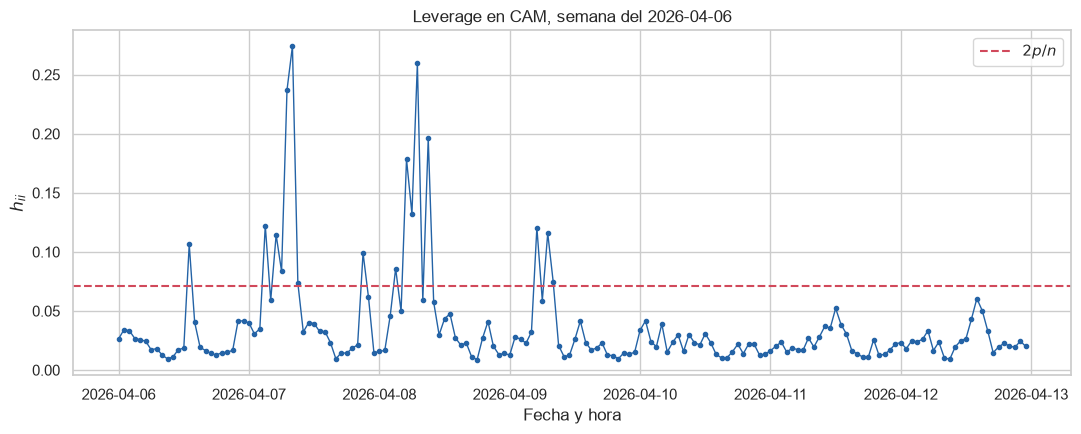

In [10]:
analisis["inicio_semana"] = analisis["date"].dt.to_period("W-SUN").dt.start_time
conteos = analisis.groupby(["id_station", "inicio_semana"], sort=True).size()
estacion_elegida, semana_elegida = conteos.idxmax()

semana = analisis.loc[
    (analisis["id_station"] == estacion_elegida)
    & (analisis["inicio_semana"] == semana_elegida)
].sort_values("date").copy()

X_semana = sm.add_constant(semana[pred_gases_estable], has_constant="add").to_numpy()
p_semana = np.linalg.matrix_rank(X_semana)
H = X_semana @ np.linalg.pinv(X_semana.T @ X_semana) @ X_semana.T

error_idempotencia = np.max(np.abs(H @ H - H))
error_simetria = np.max(np.abs(H - H.T))
traza_H = np.trace(H)

comprobacion_H = pd.Series({
    "estacion": estacion_elegida,
    "inicio_semana": semana_elegida,
    "n": len(semana),
    "columnas_X": X_semana.shape[1],
    "p_rango_X": p_semana,
    "max_abs(H2-H)": error_idempotencia,
    "max_abs(H-Ht)": error_simetria,
    "traza_H": traza_H,
    "abs(traza_H-p)": abs(traza_H - p_semana),
}, name="Comprobación").to_frame()
display(comprobacion_H)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(semana["date"], np.diag(H), marker="o", markersize=3, linewidth=1, color=COLOR)
ax.axhline(2 * p_semana / len(semana), color=COLOR_2, linestyle="--", label=r"$2p/n$")
ax.set(
    title=f"Leverage en {estacion_elegida}, semana del {semana_elegida:%Y-%m-%d}",
    xlabel="Fecha y hora",
    ylabel=r"$h_{ii}$",
)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Leverage de todas las observaciones sin construir H.
X_np = X.to_numpy()
xtx_inv = np.linalg.pinv(X_np.T @ X_np)
leverage = np.einsum("ij,jk,ik->i", X_np, xtx_inv, X_np)

analisis["leverage"] = leverage
p = np.linalg.matrix_rank(X_np)
n = len(analisis)
umbral_leverage = 2 * p / n

verificacion_leverage = pd.Series({
    "n": n,
    "p": p,
    "suma_leverage": leverage.sum(),
    "abs(suma_h-p)": abs(leverage.sum() - p),
    "leverage_promedio": leverage.mean(),
    "p/n": p / n,
    "umbral_2p/n": umbral_leverage,
    "n_sobre_umbral": int((leverage > umbral_leverage).sum()),
}, name="Leverage sin construir H").to_frame()
display(verificacion_leverage)

columnas_id = ["date", "id_station", objetivo, *pred_gases_estable, "leverage"]
display(analisis.nlargest(10, "leverage")[columnas_id])

,Leverage sin construir H
n,"32,686"
p,6
suma_leverage,6
abs(suma_h-p),1.78524e-13
leverage_promedio,0.000183565
p/n,0.000183565
umbral_2p/n,0.00036713
n_sobre_umbral,"2,521"


,date,id_station,PM2.5,CO,NO,NO2,O3,SO2,leverage
24936,2026-01-08 05:00:00,UAX,25,0.98,423,50,1,3,0.0180596
24986,2026-01-10 07:00:00,UAX,39,1.34,366,34,1,2,0.0112751
22540,2026-01-13 01:00:00,TLA,21,0.48,10,32,8,102,0.0106691
9420,2026-02-18 07:00:00,MER,37,2.19,365,87,5,12,0.0104482
5534,2026-02-05 20:00:00,CCA,34,0.7,0,40,54,101,0.0103014
30299,2026-02-12 03:00:00,UIZ,40,0.5,2,40,8,92,0.00858445
9300,2026-02-12 03:00:00,MER,28,0.84,13,46,7,91,0.00829872
25749,2026-02-12 05:00:00,UAX,31,0.86,288,42,1,2,0.00803347
26751,2026-03-27 05:00:00,UAX,18,0.73,272,38,1,2,0.00737299
25635,2026-02-07 07:00:00,UAX,26,1.47,308,29,1,3,0.00714967


## F. Distancia de Cook y reajuste sin las 10 observaciones más influyentes

La distancia de Cook combina residuo y leverage:

$$D_i=\frac{e_i^2}{p\,\mathrm{MSE}}\frac{h_{ii}}{(1-h_{ii})^2}.$$

Por eso una observación puede tener leverage alto pero Cook bajo si cae cerca del plano ajustado; los dos rankings no tienen por qué coincidir.

In [12]:
residuos = modelo.resid.to_numpy()
cook = (residuos**2 / (p * modelo.mse_resid)) * (leverage / (1 - leverage)**2)
analisis["residuo"] = residuos
analisis["cook"] = cook

idx_cook10 = analisis["cook"].nlargest(10).index
idx_lev10 = analisis["leverage"].nlargest(10).index
coinciden = set(idx_cook10) & set(idx_lev10)

top_cook = analisis.loc[idx_cook10, [
    "date", "id_station", objetivo, "residuo", "leverage", "cook"
]].copy()
top_cook["tambien_top10_leverage"] = top_cook.index.isin(idx_lev10)
top_cook.insert(0, "fila_original", top_cook.index)

display(top_cook)
print(f"Coincidencias entre ambos top 10: {len(coinciden)} de 10")
print(
    "¿Los 10 más influyentes son los 10 de mayor leverage? ",
    "Sí." if set(idx_cook10) == set(idx_lev10) else "No. Cook también depende del tamaño del residuo."
)

,fila_original,date,id_station,PM2.5,residuo,leverage,cook,tambien_top10_leverage
21048,21048,2026-01-01 07:00:00,SAC,323,281.437,0.00260422,0.295445,False
21044,21044,2026-01-01 03:00:00,SAC,349,304.335,0.00222801,0.295346,False
21049,21049,2026-01-01 08:00:00,SAC,296,247.22,0.00258925,0.226654,False
21043,21043,2026-01-01 02:00:00,SAC,324,280.393,0.0017668,0.198623,False
21045,21045,2026-01-01 04:00:00,SAC,290,251.675,0.00158217,0.143246,False
13918,13918,2026-01-01 05:00:00,NEZ,255,213.954,0.00171297,0.112113,False
21047,21047,2026-01-01 06:00:00,SAC,182,134.357,0.00360637,0.0934338,False
21050,21050,2026-01-01 09:00:00,SAC,305,258.737,0.000906057,0.0865833,False
13919,13919,2026-01-01 06:00:00,NEZ,289,258.252,0.000844791,0.0804164,False
21042,21042,2026-01-01 01:00:00,SAC,201,154.448,0.00208626,0.0712068,False


Coincidencias entre ambos top 10: 0 de 10
¿Los 10 más influyentes son los 10 de mayor leverage?  No. Cook también depende del tamaño del residuo.


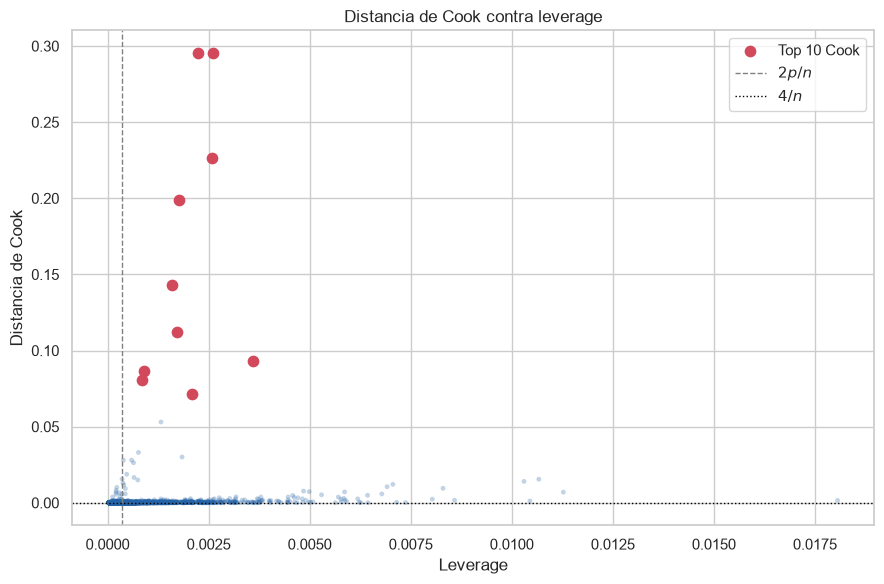

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(analisis["leverage"], analisis["cook"], s=12, alpha=0.28, color=COLOR, edgecolors="none")
ax.scatter(
    analisis.loc[idx_cook10, "leverage"], analisis.loc[idx_cook10, "cook"],
    s=55, color=COLOR_2, label="Top 10 Cook", zorder=3
)
ax.axvline(umbral_leverage, color="gray", linestyle="--", linewidth=1, label=r"$2p/n$")
ax.axhline(4 / n, color="black", linestyle=":", linewidth=1, label=r"$4/n$")
ax.set(title="Distancia de Cook contra leverage", xlabel="Leverage", ylabel="Distancia de Cook")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Reajuste después de retirar las 10 observaciones con mayor distancia de Cook.
mascara_reajuste = ~analisis.index.isin(idx_cook10)
X_reajuste = X.loc[mascara_reajuste]
y_reajuste = y.loc[mascara_reajuste]
modelo_reajustado = sm.OLS(y_reajuste, X_reajuste).fit()

coeficientes = pd.DataFrame({
    "modelo_original": modelo.params,
    "sin_top10_Cook": modelo_reajustado.params,
})
coeficientes["cambio"] = coeficientes["sin_top10_Cook"] - coeficientes["modelo_original"]
coeficientes["cambio_porcentual_abs"] = np.where(
    coeficientes["modelo_original"].abs() > 1e-12,
    100 * coeficientes["cambio"].abs() / coeficientes["modelo_original"].abs(),
    np.nan,
)

pred_original_misma_muestra = modelo.predict(X)
pred_reajustado_misma_muestra = modelo_reajustado.predict(X)
sst_original = np.sum((y - y.mean())**2)

comparacion_reajuste = pd.DataFrame({
    "modelo": ["Original", "Sin top 10 Cook"],
    "n_ajuste": [len(y), len(y_reajuste)],
    "R2_en_muestra_de_ajuste": [modelo.rsquared, modelo_reajustado.rsquared],
    "RMSE_en_muestra_de_ajuste": [
        np.sqrt(np.mean(modelo.resid**2)),
        np.sqrt(np.mean(modelo_reajustado.resid**2)),
    ],
    # Evaluación de ambos modelos sobre las mismas observaciones originales.
    "R2_sobre_muestra_original": [
        1 - np.sum((y - pred_original_misma_muestra)**2) / sst_original,
        1 - np.sum((y - pred_reajustado_misma_muestra)**2) / sst_original,
    ],
    "RMSE_sobre_muestra_original": [
        np.sqrt(np.mean((y - pred_original_misma_muestra)**2)),
        np.sqrt(np.mean((y - pred_reajustado_misma_muestra)**2)),
    ],
})

display(coeficientes)
display(comparacion_reajuste)
print(
    "La comparación sobre la muestra original mantiene fijo el conjunto de evaluación; "
    "la comparación en la muestra de ajuste usa el conjunto propio de cada modelo."
)

,modelo_original,sin_top10_Cook,cambio,cambio_porcentual_abs
const,1.58838,1.61522,0.0268341,1.6894
CO,11.5361,8.69252,-2.84363,24.6497
NO,-0.0221205,-0.00750987,0.0146106,66.0501
NO2,0.252498,0.301857,0.049359,19.5483
O3,0.165709,0.169179,0.00347002,2.09405
SO2,0.355602,0.350827,-0.0047753,1.34288


,modelo,n_ajuste,R2_en_muestra_de_ajuste,RMSE_en_muestra_de_ajuste,R2_sobre_muestra_original,RMSE_sobre_muestra_original
0,Original,32686,0.316691,10.8143,0.316691,10.8143
1,Sin top 10 Cook,32676,0.342393,9.92074,0.314803,10.8292


La comparación sobre la muestra original mantiene fijo el conjunto de evaluación; la comparación en la muestra de ajuste usa el conjunto propio de cada modelo.


## Conclusiones

- Covarianza y correlación de CO con NOX miden asociación lineal, pero sólo la correlación está estandarizada.
- El tratamiento de faltantes cambia tanto la muestra como los eigenvalores de la matriz de correlación. La eliminación por pares puede producir una matriz que no sea semidefinida positiva.
- El $R^2$ y el VIF revelan relaciones estructurales entre variables (`NOX`, `NO`, `NO2` y las fracciones de partículas); deben interpretarse antes de atribuir capacidad predictiva al modelo.
- La idempotencia, simetría y traza de $H$ se verifican numéricamente en una semana. Para la base completa basta calcular $h_{ii}$, sin reservar memoria para una matriz $n\times n$.
- Cook y leverage no son equivalentes: Cook combina posición extrema y residuo. El reajuste final permite medir cuánto cambian los coeficientes y el desempeño al retirar las diez observaciones más influyentes.